Analysis of Seismic Activity at Mount Vesuvius, using open data from the Italian Istituto Nazionale di Geofisica e Vulcanologia (INGV).

> **_Introductory note_**:
>
> To begin this data analysis journey, I'd like to mention that one of the objectives of this `Blog Posts` section is to approach data I'm not familiar with. All my work experience in the automotive industry so far has been related to logistics, material and information flow, quality, cost, production volume, budgeting and maintenance.

Now, let's get to it.

I found this Github repository called [TidyTuesday](https://github.com/rfordatascience/tidytuesday/tree/main?tab=readme-ov-file) a few years ago which, according to its description _"... is a weekly social data project..."_ and _"Our over-arching goal for TidyTuesday is to provide real-world datasets so that people can learn to work with data."_

They have an abundant quantity of datasets, organized by year, week and date of publication, starting from 2018. This is where I'm getting this `Seismic events` dataset from.

## Dataset General Information

Taken from the TidyTuesday [post](https://github.com/rfordatascience/tidytuesday/blob/main/data/2025/2025-05-13/readme.md):
> The dataset this week explores seismic events detected at the famous Mount Vesuvius in Italy. It comes from the [Italian Istituto Nazionale di Geofisica e Vulcanologia (INGV)](https://www.ingv.it/)'s [Data Portal](https://data.ingv.it/en/) and can be explored along with other seismic areas on the [GOSSIP website](https://terremoti.ov.ingv.it/gossip/vesuvio/index.html). The raw data was saved as individual CSV files from the GOSSIP website and some values were translated from Italian to English.

## 1. Data Loading

Source: [https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-05-13/vesuvius.csv]

In [75]:
# import libraries
import pandas as pd
import numpy as np
from IPython.display import display # we'll use DISPLAY to get a friendlier, easier-to-read printing format
from warnings import filterwarnings

# ignore warnings
filterwarnings('ignore')

# load the dataset
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-05-13/vesuvius.csv"
df = pd.read_csv(url)

In [76]:
# Display the first rows of the dataframe and shape
display(df.head())
print("dataframe size is:", df.shape)

,event_id,time,latitude,longitude,depth_km,duration_magnitude_md,md_error,area,type,review_level,year
0,4251,2011-04-20T00:27:24Z,40.818000,14.430000,0.42,1.2,0.3,Mount Vesuvius,earthquake,revised,2011
1,4252,2012-06-19T21:29:48Z,40.808833,14.427167,1.31,0.7,0.3,Mount Vesuvius,earthquake,revised,2012
2,22547,2013-01-01T07:34:46Z,40.822170,14.428000,0.06,2.2,0.3,Mount Vesuvius,earthquake,preliminary,2013
3,22546,2013-01-03T16:06:48Z,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013
4,22545,2013-01-03T16:07:37Z,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013


dataframe size is: (12027, 11)


Also taken from the post, the description of the dataset fields:

|variable|	class|	description|
|--------|-------|-------------|
|event_id|	integer|	Unique identifier for each seismic event recorded.|
|time|	datetime|	Date and time when the seismic event occurred, in UTC format.|
|latitude|	double|	Geographic latitude of the seismic event location in decimal degrees.|
|longitude|	double|	Geographic longitude of the seismic event location in decimal degrees.|
|depth_km|	double|	Depth of the seismic event epicenter in kilometers below the surface.|
|duration_magnitude_md|	double|	Duration magnitude (Md) of the seismic event, a measure of its energy release. Md is often used for smaller magnitude events, and negative values can indicate very small events (microearthquakes).
|md_error|	double|	Estimated error margin ("plus or minus") for the duration magnitude measurement.|
|area|	character|	Geographic area where the seismic event was recorded. In this case, the Mt. Vesuvius area.|
|type|	character|	Classification of the seismic event, such as "earthquake" or "eruption."|
|review_level|	character|	Level of review the data has undergone. The data might be raw (preliminary) or revised (reviewed by someone).|
|year|	integer|	Calendar year when the seismic event occurred.|

We have a total of 11 variables and 12k registries

## 2. Data Exploration

Let's begin by exploring the contents of each variable and, in general, evaluate the following:
> * Data completeness
> * Data cleanliness
> * Data types
> * Remove duplicate rows
> * Find missing/NA values
> * Check for any possible anomaly

This will also allow us to get a better understanding of the dataset

First, count the values for each field and some statistics for numerical columns:

In [77]:
# Review the contents of each variable
df.info()

# Describe the numerical fields
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 12027 entries, 0 to 12026
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_id               12027 non-null  int64  
 1   time                   12027 non-null  str    
 2   latitude               8594 non-null   float64
 3   longitude              8594 non-null   float64
 4   depth_km               8594 non-null   float64
 5   duration_magnitude_md  11628 non-null  float64
 6   md_error               11628 non-null  float64
 7   area                   12027 non-null  str    
 8   type                   12027 non-null  str    
 9   review_level           12027 non-null  str    
 10  year                   12027 non-null  int64  
dtypes: float64(5), int64(2), str(4)
memory usage: 1.0 MB


,event_id,latitude,longitude,depth_km,duration_magnitude_md,md_error,year
count,12027.000000,8594.000000,8594.000000,8594.000000,11628.000000,1.162800e+04,12027.000000
mean,15494.115740,40.820715,14.427410,0.406770,0.177097,3.000000e-01,2018.877692
std,11014.195422,0.003280,0.004525,0.497769,0.556318,5.551354e-17,3.279678
min,102.000000,40.798828,14.349167,0.010000,-2.000000,3.000000e-01,2011.000000
25%,5965.500000,40.819000,14.424670,0.140000,-0.200000,3.000000e-01,2016.000000
50%,14981.000000,40.820839,14.427167,0.240000,0.100000,3.000000e-01,2019.000000
75%,21387.500000,40.822670,14.430170,0.427500,0.500000,3.000000e-01,2022.000000
max,40802.000000,40.860500,14.475330,9.350000,3.100000,3.000000e-01,2024.000000


As we can see, there are fields like `latitude` and `md_error` with a count of less than 12027 entries. We need to understand why.

In [78]:
# Print number of null values
print('* Number of null values in each column:' )
print(df.isnull().sum())
# Print number of empty strings
print('* Number of empty strings in each column:' )
print(df[df == ""].sum())

* Number of null values in each column:
event_id                    0
time                        0
latitude                 3433
longitude                3433
depth_km                 3433
duration_magnitude_md     399
md_error                  399
area                        0
type                        0
review_level                0
year                        0
dtype: int64
* Number of empty strings in each column:
event_id                 0.0
time                       0
latitude                 0.0
longitude                0.0
depth_km                 0.0
duration_magnitude_md    0.0
md_error                 0.0
area                       0
type                       0
review_level               0
year                     0.0
dtype: object


We have some null values, but zero empty strings. This simplifies data cleaning a bit.

Just to be sure, I will confirm if the row index for all missing values of `latitude`, `longitude` and `depth_km` are the same:

In [79]:
# Create a variable for each list of indexes
latitude_null_index = df[df['latitude'].isnull()].index
longitude_null_index = df[df['longitude'].isnull()].index
depth_km_null_index = df[df['depth_km'].isnull()].index

# Compare each variable
if (set(latitude_null_index) == set(longitude_null_index)) and (set(longitude_null_index) == set(depth_km_null_index)):
    print("✅ All index sets are equal")
else:
    print("❌ Not all index sets are equal")

✅ All index sets are equal


💡 Why use `set()` to compare lists of indexes?

When you compare lists or indexes using `==`, order matters. For example:
```
[1, 2] == [2, 1]  # ❌ False
```
But if you convert both to `set()`:
```
set([1, 2]) == set([2, 1])  # ✅ True
```

This is especially useful when comparing null indexes because:
* The order of the indexes usually doesn’t matter.
* What matters is which rows have null values, not the order in which they appear.

Before more in-depth analysis of the three previous variables, I'd like to know the date range:

In [80]:
# Check the min and max values of `time`. It has dtype <object>. Let's try to check the values before any type conversion
print('Min time value: ', min(df['time']), ' ... ', 'Max time value: ', max(df['time']))

Min time value:  2011-04-20T00:27:24Z  ...  Max time value:  2024-12-31T17:02:32Z


The dataset registers seismic activity from april 2011 up to the end of 2024.

---

**Visual Exploration**

Let's start analyzing the fields `latitude`, `longitude` and `depth_km`, and try to understand why there are missing values.

First, create a histogram for each column:

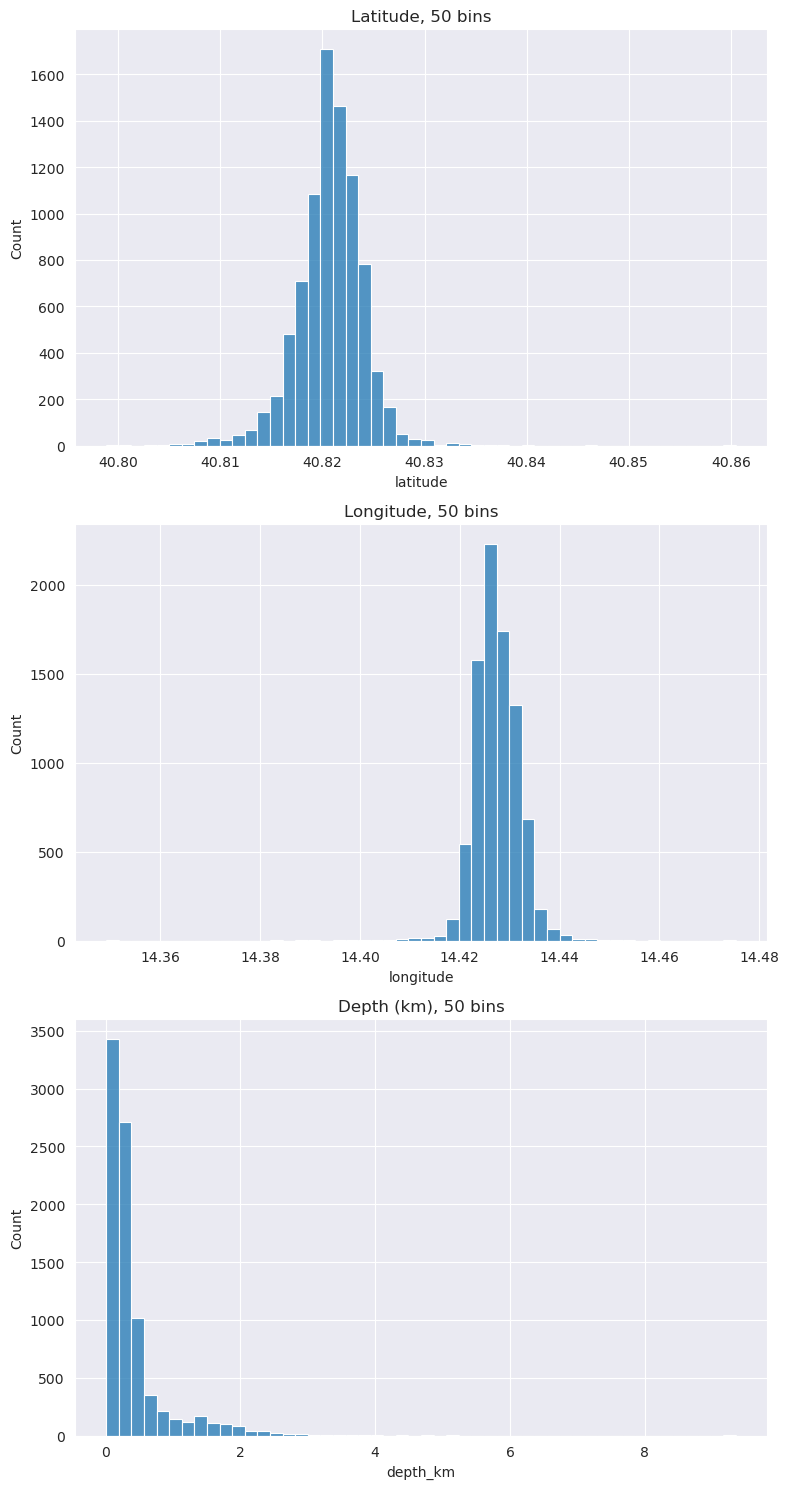

In [81]:
## Explore latitude, longitude and depth_km

# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Set the style of seaborn plots to 'darkgrid'
sns.set_style("darkgrid")

# Define dictionary with column names and title
column_names = {
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'depth_km': 'Depth (km)'
}

# Create 3-figure subplots for histograms
fig, axes = plt.subplots(3, 1, figsize=(8, 15))

# Plot histograms for latitude, longitude, and depth_km
for i, (col, name) in enumerate(column_names.items()):
    sns.histplot(data=df, x=col, bins=50, ax=axes[i])
    axes[i].set_title(f"{name}, 50 bins")

plt.tight_layout()
plt.show()

Both `latitude` and `longitude` are close to a normal distribution and have a very small spread (st. deviation less than 0,005). On the other hand, `depth_km` shows a highly right-skewed distribution, where the majority of data is cluster at lower depths with rapid decline in frequency as depth increases.

How does the dataset look where `latitude` (which applies the same for `longitude` and `depth_km`) is null?

In [82]:
# Display the dataframe where latitude is empty or null
display(df[df['latitude'].isnull()])

,event_id,time,latitude,longitude,depth_km,duration_magnitude_md,md_error,area,type,review_level,year
3,22546,2013-01-03T16:06:48Z,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013
4,22545,2013-01-03T16:07:37Z,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013
5,22544,2013-01-04T06:42:50Z,NaN,NaN,NaN,0.0,0.3,Mount Vesuvius,earthquake,preliminary,2013
6,22543,2013-01-04T18:37:31Z,NaN,NaN,NaN,0.8,0.3,Mount Vesuvius,earthquake,preliminary,2013
7,22542,2013-01-05T01:55:31Z,NaN,NaN,NaN,1.4,0.3,Mount Vesuvius,earthquake,preliminary,2013
...,...,...,...,...,...,...,...,...,...,...,...
12001,40623,2024-12-14T19:10:35Z,NaN,NaN,NaN,-0.4,0.3,Mount Vesuvius,earthquake,preliminary,2024
12008,40648,2024-12-18T06:33:08Z,NaN,NaN,NaN,-0.4,0.3,Mount Vesuvius,earthquake,preliminary,2024
12013,40681,2024-12-22T02:37:38Z,NaN,NaN,NaN,0.1,0.3,Mount Vesuvius,earthquake,preliminary,2024
12019,40720,2024-12-28T05:59:16Z,NaN,NaN,NaN,-0.6,0.3,Mount Vesuvius,earthquake,preliminary,2024


I find interesting that, for those events where latitude is empty, the `duration_magnitude_md` is very low (or close to zero). 
Let's compare how the `duration_magnitude_md` series is distributed for all data vs when `latitude` is null.

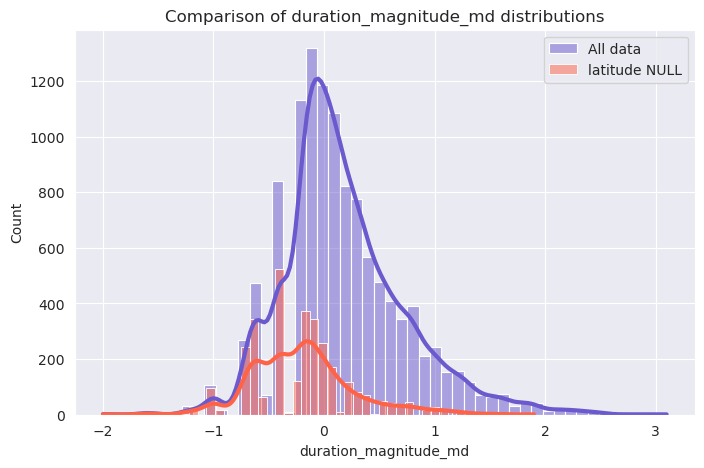

In [83]:
import matplotlib.dates as mdates # For date formatting later in time series plots

# Create figure and a single axis
plt.figure(figsize=(8, 5))
ax = plt.gca()

# Chart 1: All data
sns.histplot(
    data=df, 
    x='duration_magnitude_md', 
    bins=50,
    color='#6A5ACD',
    alpha=0.5,  # transparencia
    label='All data',
    kde=True,
    line_kws={'lw': 3},
    ax=ax
)

# Chart 2: 'latitude' IS null
sns.histplot(
    data=df[df['latitude'].isnull()],
    x='duration_magnitude_md',
    bins=50,
    color='#FF6347',
    alpha=0.5,
    label='latitude NULL',
    kde=True,
    line_kws={'lw': 3},
    ax=ax
)

# Add legend and title
ax.set_title("Comparison of duration_magnitude_md distributions")
ax.legend()

plt.show()

**Initial Conclusion**

There is some displacement to the left of the distribution when `latitude` is null in comparison to the general distribution, suggesting (but not confirmed yet) that the lack of a latitude (and thus, longitude as well) value **is not a random event** within the dataset. There could be a correlation between having a null `latitude` and the values of  `duration_magnitude_md`.

Specifically, data points where the `latitude` is null tend to have lower values of `duration_magnitude_md` compared to the overall dataset and particularly, values less than zero.

Reviewing the description of the columns again, we can see that:

>  `duration_magnitude_md`: Duration magnitude (Md) of the seismic event, a measure of its energy release. Md is often used for smaller magnitude events, and **negative values can indicate very small events (microearthquakes)**. 

And lastly, since variables `duration_magnitude_md` and `md_error` are related, we can confidently asume that the missing (null) values correspond to the same row index.

---

Let's make a scatter plot on a map using our coordinates:

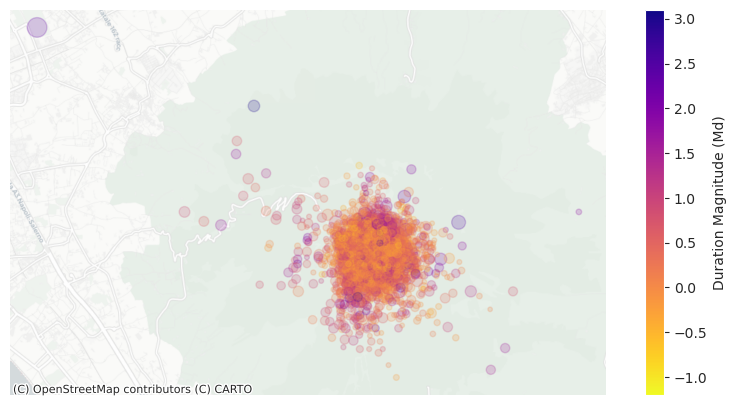

In [84]:
import geopandas as gpd
import contextily as ctx

# Filter out missing 'latitude' and 'md_error' rows
df_filtered = df[df['latitude'].notna() & df['md_error'].notna()]

# GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_filtered,
    geometry=gpd.points_from_xy(df_filtered['longitude'], df_filtered['latitude']),
    crs="EPSG:4326"
)

# Reproject
gdf = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

# Markersize
min_size = 10
max_size = 200

size = (
    (df_filtered['depth_km'] - df_filtered['depth_km'].min()) /
    (df_filtered['depth_km'].max() - df_filtered['depth_km'].min())
) * (max_size - min_size) + min_size

gdf.plot(
    ax=ax,
    column='duration_magnitude_md',
    cmap='plasma_r',
    markersize=size,
    alpha=0.2,
    legend=True,
    legend_kwds={'label': 'Duration Magnitude (Md)'}
)

# Basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

**Categorical fields**

I would like to know the unique values of the categorical variables: [`area`, `type`, `review_level`]

In [85]:
df[['area', 'type', 'review_level']].apply(lambda col: col.unique())

area                  [Mount Vesuvius]
type                      [earthquake]
review_level    [revised, preliminary]
dtype: object

Only the `review_level` field contains more than one unique value.

Interestingly, only 2 entries are labeled as _revised_ , while all others fall under the _preliminary_ category. 
The three categorical fields don't add too much information to the dataset. We already know that seismic events were recorded around Mount Vesuvius, and on latitude and longitude locations practically identical.

In [86]:
# Count the number of values for each review level
df['review_level'].value_counts()

review_level
preliminary    12025
revised            2
Name: count, dtype: int64

___
**How about some time series analysis now?**

To perform time series analysis, we'll do the following:
* Convert the `time` field to a proper timedate type.
* Add time frames for week,  month number and month name

In [87]:
# Filter out years 2011 and 2012 (only 1 event each)
df = df[df['year'] > 2012]

# Convert 'time' to datetime
df['time'] = pd.to_datetime(df['time'], errors='raise')

# Add time frame columns
df['date'] = df['time'].dt.date  # Date without time
df['week'] = df['time'].dt.strftime('%G%V')  # ISO week format (e.g., '2023W01')
df['month_name'] = df['time'].dt.month_name() + ' ' + df['time'].dt.year.astype(str)  # e.g., 'January 2023'
df['quarter'] = df['time'].dt.to_period('Q').astype(str)  # e.g., '2023Q1'
df['short_month_name'] = df['time'].dt.month_name().str[:3] + ' ' + df['time'].dt.year.astype(str)  # e.g., 'Jan 2023'

# Display the first rows and shape
display(df.head())

,event_id,time,latitude,longitude,depth_km,duration_magnitude_md,md_error,area,type,review_level,year,date,week,month_name,quarter,short_month_name
2,22547,2013-01-01 07:34:46+00:00,40.82217,14.428,0.06,2.2,0.3,Mount Vesuvius,earthquake,preliminary,2013,2013-01-01,201301,January 2013,2013Q1,Jan 2013
3,22546,2013-01-03 16:06:48+00:00,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013,2013-01-03,201301,January 2013,2013Q1,Jan 2013
4,22545,2013-01-03 16:07:37+00:00,NaN,NaN,NaN,0.2,0.3,Mount Vesuvius,earthquake,preliminary,2013,2013-01-03,201301,January 2013,2013Q1,Jan 2013
5,22544,2013-01-04 06:42:50+00:00,NaN,NaN,NaN,0.0,0.3,Mount Vesuvius,earthquake,preliminary,2013,2013-01-04,201301,January 2013,2013Q1,Jan 2013
6,22543,2013-01-04 18:37:31+00:00,NaN,NaN,NaN,0.8,0.3,Mount Vesuvius,earthquake,preliminary,2013,2013-01-04,201301,January 2013,2013Q1,Jan 2013


Then, create line plots for each time frame: yearly, quarterly, monthly, weekly and daily.

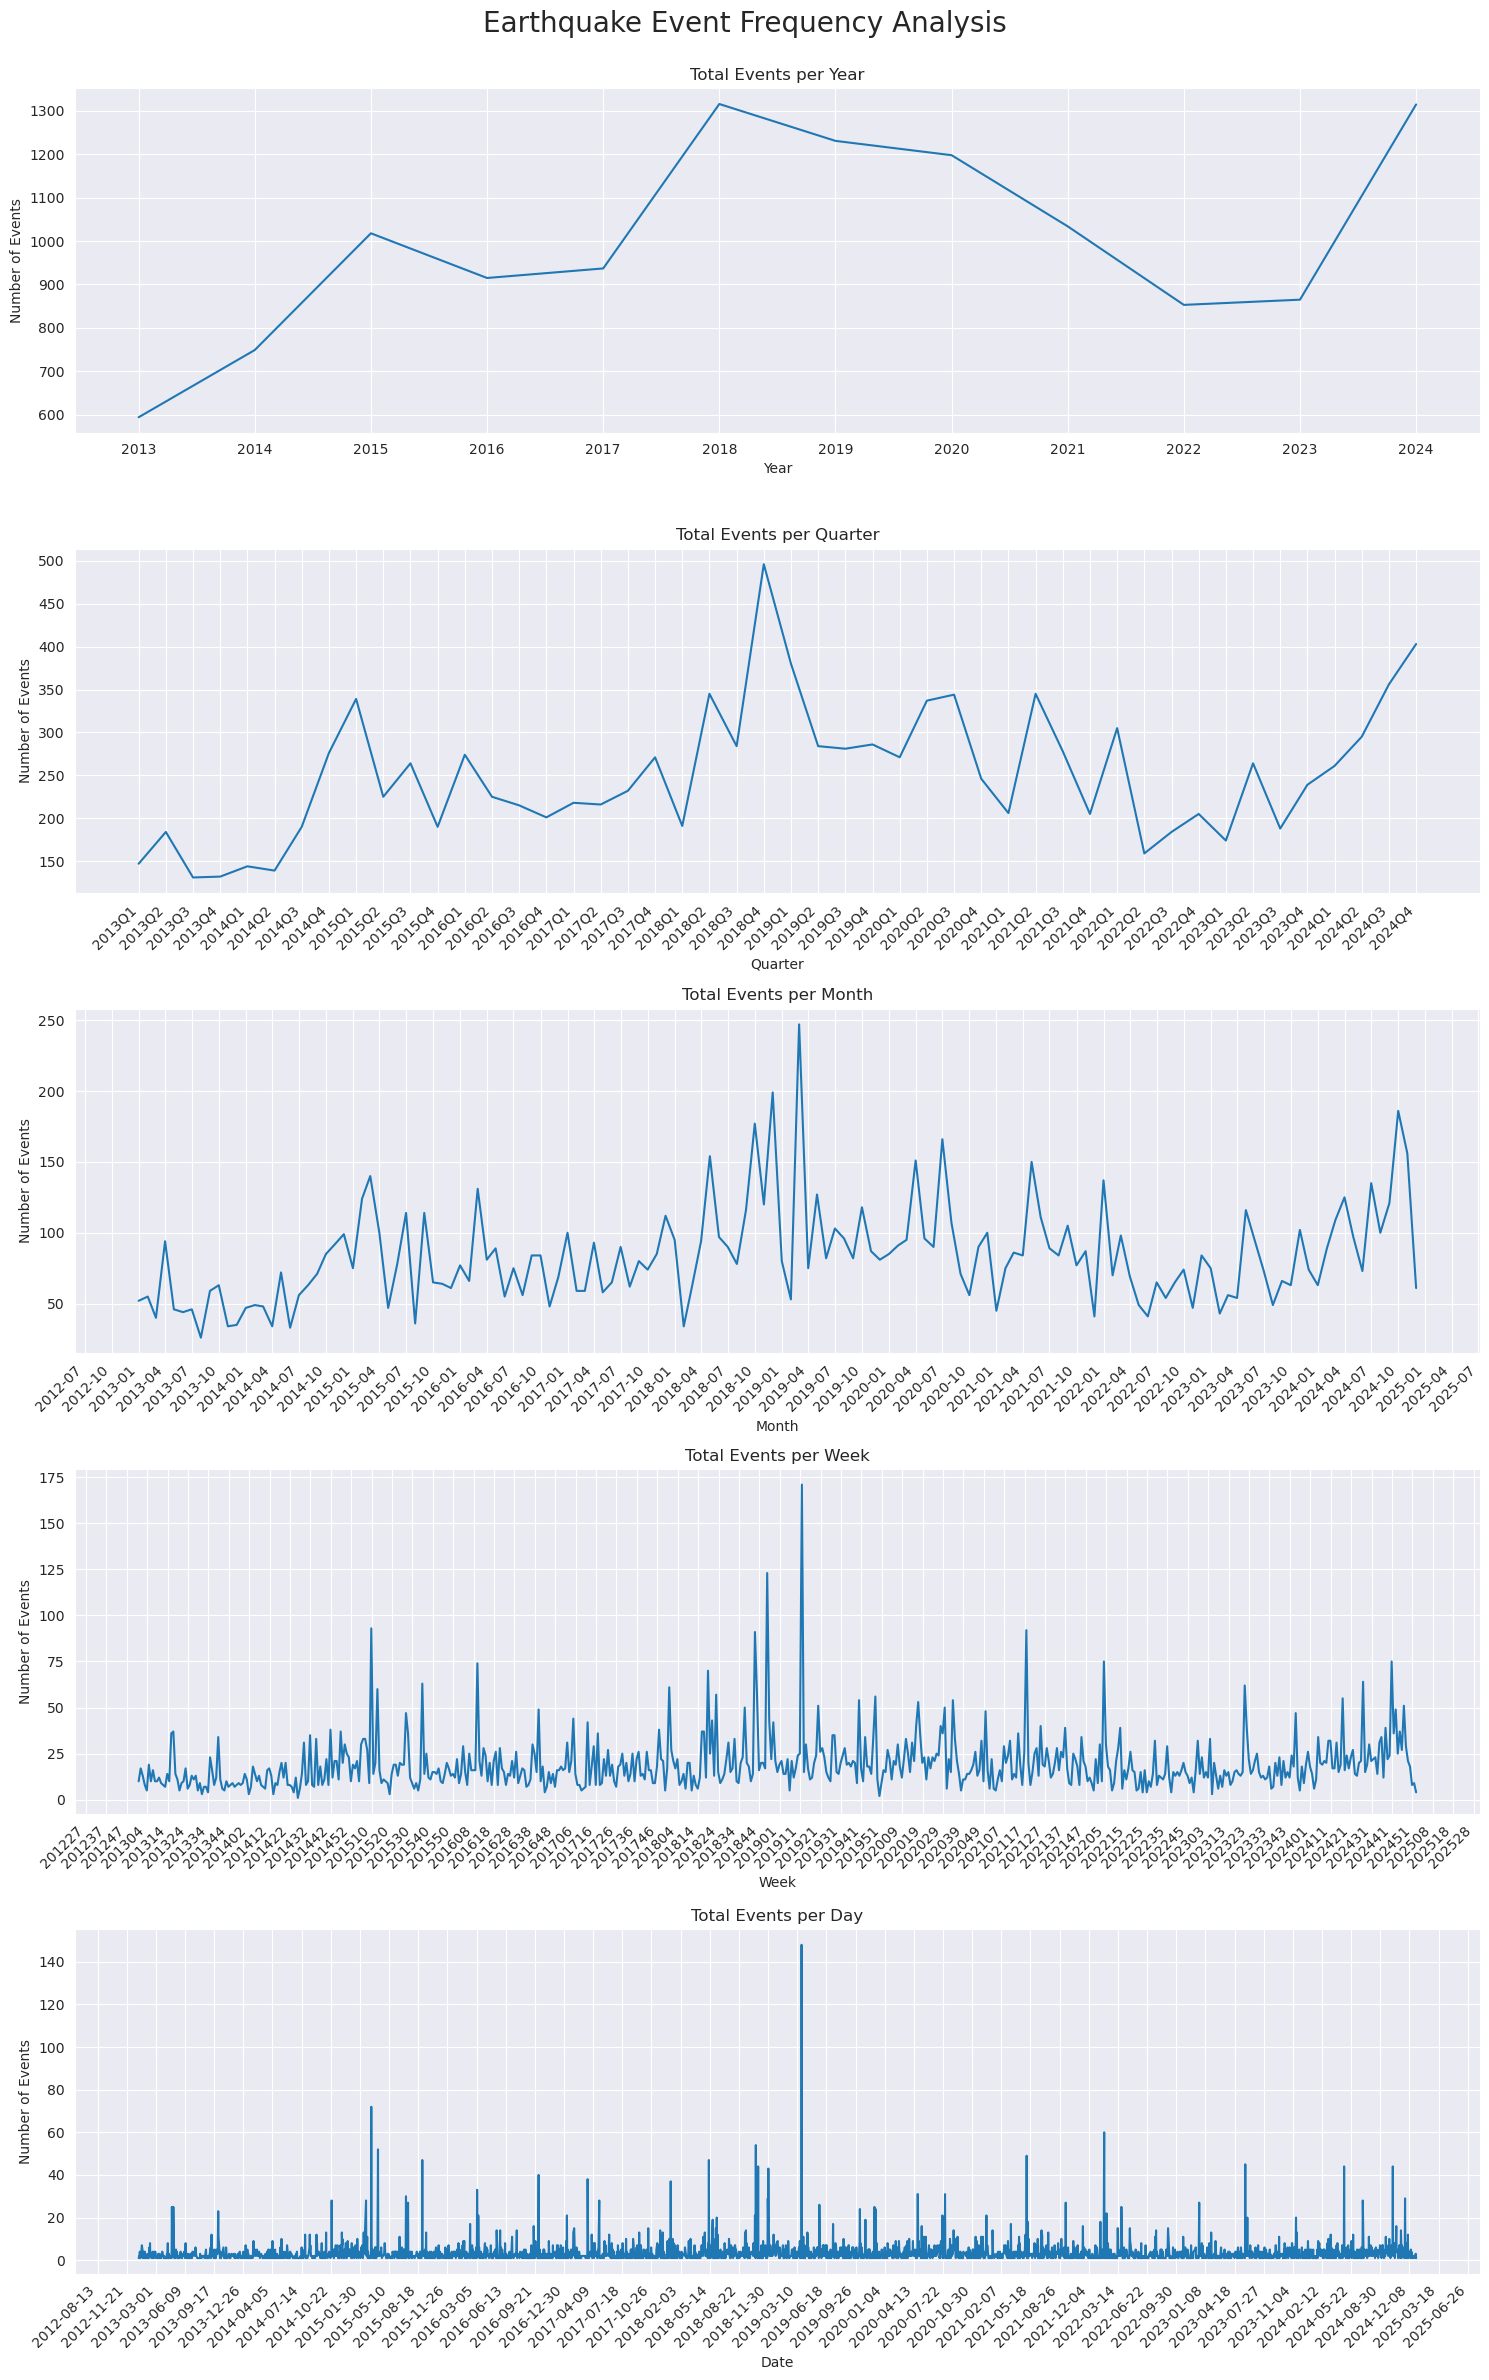

In [88]:
## Line plots in different time frames
# Set the style for the plots
# sns.set_style("darkgrid")  # In case you want to set a specific style for the plots

# Create a figure with subplots
fig, axes = plt.subplots(5, 1, figsize=(15, 25))
fig.suptitle('Earthquake Event Frequency Analysis', fontsize=20)

# 1. Yearly Analysis
yearly_counts = df['year'].value_counts().sort_index()
sns.lineplot(ax=axes[0], x=yearly_counts.index, y=yearly_counts.values)
axes[0].set_title('Total Events per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Events')
axes[0].set_xticks(yearly_counts.index)  # Show all years

# 2. Quarterly Analysis
quarterly_counts = df['quarter'].value_counts().sort_index()
sns.lineplot(ax=axes[1], x=quarterly_counts.index, y=quarterly_counts.values)
axes[1].set_title('Total Events per Quarter')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Number of Events')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

# 3. Monthly Analysis
monthly_counts = df.groupby(df['time'].dt.to_period('M')).size()
sns.lineplot(ax=axes[2], x=monthly_counts.index.to_timestamp(), y=monthly_counts.values)
axes[2].set_title('Total Events per Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Number of Events')
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Ticks every 3 months
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as 'YYYY-MM'
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

# 4. Weekly Analysis
weekly_counts = df.groupby(df['time'].dt.to_period('W')).size()
sns.lineplot(ax=axes[3], x=weekly_counts.index.to_timestamp(), y=weekly_counts.values)
axes[3].set_title('Total Events per Week')
axes[3].set_xlabel('Week')
axes[3].set_ylabel('Number of Events')
axes[3].xaxis.set_major_locator(mdates.WeekdayLocator(interval=10))  # Ticks every 4 weeks
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y%W'))  # Format as 'YYYYWW'
plt.setp(axes[3].get_xticklabels(), rotation=45, ha="right")

# 5. Daily Analysis
daily_counts = df['date'].value_counts().sort_index()
daily_counts.index = pd.to_datetime(daily_counts.index)  # Ensure datetime index
sns.lineplot(ax=axes[4], x=daily_counts.index, y=daily_counts.values)
axes[4].set_title('Total Events per Day')
axes[4].set_xlabel('Date')
axes[4].set_ylabel('Number of Events')
axes[4].xaxis.set_major_locator(mdates.DayLocator(interval=100))  # Ticks every month
axes[4].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format as 'YYYY-MM'
plt.setp(axes[4].get_xticklabels(), rotation=45, ha="right")

# Adjust layout and display
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### A few comments and conclusions here:

**1. Total Events per Year:** 
This plot gives us the long-term trend over the last decade.

* Overall Trend: There is a clear upward trend in the number of seismic events from 2013 to 2024.

* Peak Activity: The activity peaked in 2018, which stands out as the year with the highest number of recorded events (over 1300).

* Periods of Change: After the 2018 peak, there was a slight decline and stabilization period until about 2022. From 2022 to 2024, the activity appears to be on the rise again

**Conclusion**: On an annual basis, the area has become more seismically active over this period, with 2018 being a particularly active year.

**2. Total Events per Quarter:**
This chart breaks down the yearly trend and reveals more detailed seasonal or periodic patterns.

* Volatility: The quarterly data is much more volatile than the annual data. It shows that the increase in yearly events is not a smooth process but is driven by * specific quarters with very high activity.

* Identifying Peaks: The 2018 annual peak is clearly attributable to very high activity in the second and third quarters.

* Recent Trend: The chart clearly shows a strong, consistent rise in activity from 2013 to 2018, and again throughout 2023 up to 2024, confirming the recent upward trend seen in the annual chart. You can see this same behaviour in the Monthly and Weekly plots

**Conclusion**: The quarterly view highlights the episodic nature of the seismic activity. The long-term trend is composed of periods of relative quiet followed by significant bursts of activity lasting one or more quarters.

**3. Total Events per Month and per Week:**
These two plots provide an even more granular view.

* Identifying Peaks: Even though 2018 is the year with the most events, 2019 shows a period of extreme seismic activity, of over 150 which can be seen again in the daily chart, around march

* Lack of Seasonality: There doesn't appear to be a simple, repeating seasonal pattern. The timing of peak months seems irregular from year to year.

**Conclusion**: The monthly chart confirms that the activity is concentrated in short, intense bursts rather than being evenly distributed throughout the year.

**4. Total Events per Day:**
This chart shows the finest level of detail.

* Volatility and Behavior: The plot shows that most days have a very low number of events. The activity is dominated by sharp, narrow spikes, which represent days with a sudden burst of many events.

* Major Events: The largest single spike on this chart corresponds to the peak activity in 2019, indicating a day of intense seismic release.

**Conclusion**: The daily view provides the strongest evidence that the seismic activity occurs in concentrated spikes. The overall increase in yearly events is due to either more frequent or more intense swarms over time.
___

## **Overall Summary**

Synthesizing the information from all plots, we can conclude that the seismic activity in the region of Mount Vesuvius has been increasing from 2013 to 2024. This activity is not constant but is characterized by periods of intense, concentrated spikes that punctuate longer periods of relative calmness. The year 2018 stands out as a time of maximum activity, 2019 as having the day with the most extreme seismic release, and there are signs of renewed increasing activity from around mid 2022 to 2024.